In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Data/processed/customer_churn_processed.csv")

df.head()

,Customer_ID,Age,Tenure_Months,Subscription_Plan,Billing_Frequency,Monthly_Charges,Login_Count_30D,Login_Count_7D,Usage_Minutes_30D,Usage_Minutes_7D,Avg_Session_Minutes_30D,Avg_Session_Minutes_7D,Support_Tickets,Open_Tickets,Avg_Resolution_Hours,Payment_Delays,Discount_Percent,NPS_Score,Days_Since_Last_Login,Churn
0,CUST10000,56.0,6,Basic,Monthly,449.04,17,11,262,237,8.7,8.2,3,1,22.4,0,10,35.0,12,1
1,CUST10001,46.0,15,Premium,Annual,1194.07,10,6,209,215,16.7,15.7,0,0,13.9,0,15,62.0,2,0
2,CUST10002,32.0,18,Standard,Monthly,736.96,19,18,209,168,17.9,18.0,4,2,19.0,0,10,63.0,7,0
3,CUST10003,60.0,32,Premium,Annual,1061.74,19,7,223,30,20.2,16.8,1,0,8.1,1,0,15.0,5,1
4,CUST10004,25.0,11,Standard,Monthly,550.54,14,7,233,87,14.9,9.6,1,1,16.0,0,0,38.0,10,1


In [3]:
#BASI STATISTICS
print("Dataset Shape:", df.shape)

print("\nStatistical Summary:")
display(df.describe())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Dataset Shape: (3000, 20)

Statistical Summary:


,Age,Tenure_Months,Monthly_Charges,Login_Count_30D,Login_Count_7D,Usage_Minutes_30D,Usage_Minutes_7D,Avg_Session_Minutes_30D,Avg_Session_Minutes_7D,Support_Tickets,Open_Tickets,Avg_Resolution_Hours,Payment_Delays,Discount_Percent,NPS_Score,Days_Since_Last_Login,Churn
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,41.545333,24.721000,690.888073,15.073333,10.140333,230.167000,157.793667,17.962967,16.034967,2.226000,0.766667,21.908067,0.711667,5.481667,42.455000,7.926333,0.288333
std,13.647125,13.829181,290.251798,3.703763,4.613430,14.896165,56.416422,5.868156,6.170681,1.476364,0.850762,15.162567,0.849767,6.091417,24.214901,2.784389,0.453063
min,18.000000,1.000000,227.580000,4.000000,1.000000,182.000000,27.000000,3.000000,2.000000,0.000000,0.000000,0.300000,0.000000,0.000000,-10.000000,0.000000,0.000000
25%,30.000000,13.000000,428.737500,13.000000,7.000000,220.000000,125.000000,13.900000,11.375000,1.000000,0.000000,10.800000,0.000000,0.000000,25.000000,6.000000,0.000000
50%,42.000000,24.000000,672.205000,15.000000,10.000000,230.000000,163.000000,17.800000,15.900000,2.000000,1.000000,18.600000,1.000000,5.000000,43.000000,8.000000,0.000000
75%,53.000000,37.000000,766.462500,18.000000,13.000000,240.000000,203.000000,21.900000,20.200000,3.000000,1.000000,29.300000,1.000000,10.000000,59.000000,10.000000,1.000000
max,65.000000,48.000000,1393.920000,28.000000,20.000000,280.000000,278.000000,38.000000,38.600000,10.000000,5.000000,104.600000,6.000000,20.000000,100.000000,23.000000,1.000000



Churn Distribution:
Churn
0    2135
1     865
Name: count, dtype: int64

Churn Percentage:
Churn
0    71.166667
1    28.833333
Name: proportion, dtype: float64


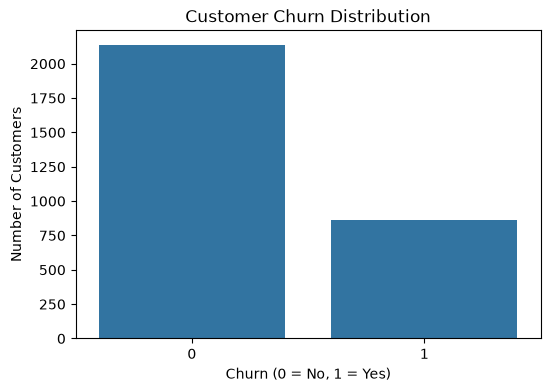

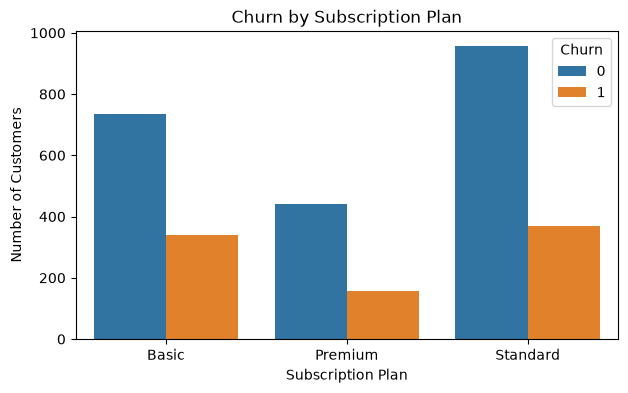

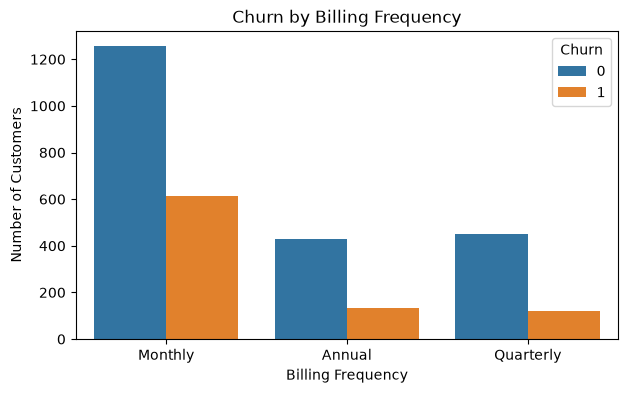

In [6]:
#Churn distribution graph
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

#Plan-wise churn
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Subscription_Plan", hue="Churn")
plt.title("Churn by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Number of Customers")
plt.show()

#Billing-wise churn
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Billing_Frequency", hue="Churn")
plt.title("Churn by Billing Frequency")
plt.xlabel("Billing Frequency")
plt.ylabel("Number of Customers")
plt.show()

In [7]:
#7D vs 30D Login
df["Login_7D_Expected"] = df["Login_Count_30D"] / 30 * 7

df["Login_Drop_Percent"] = (
    (df["Login_7D_Expected"] - df["Login_Count_7D"])
    / df["Login_7D_Expected"]
) * 100

df["Login_Drop_Percent"] = df["Login_Drop_Percent"].clip(0, 100)

df[[
    "Login_Count_30D",
    "Login_Count_7D",
    "Login_Drop_Percent",
    "Churn"
]].head()

,Login_Count_30D,Login_Count_7D,Login_Drop_Percent,Churn
0,17,11,0.0,1
1,10,6,0.0,0
2,19,18,0.0,0
3,19,7,0.0,1
4,14,7,0.0,1


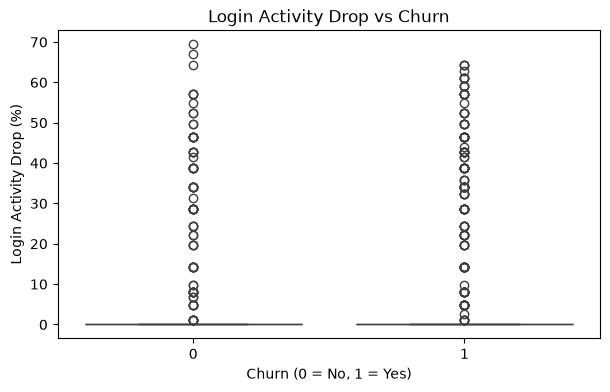

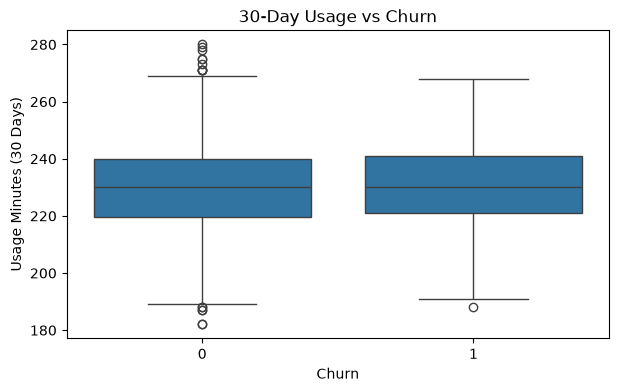

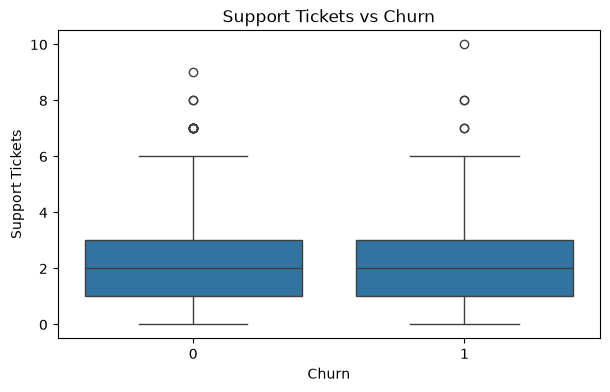

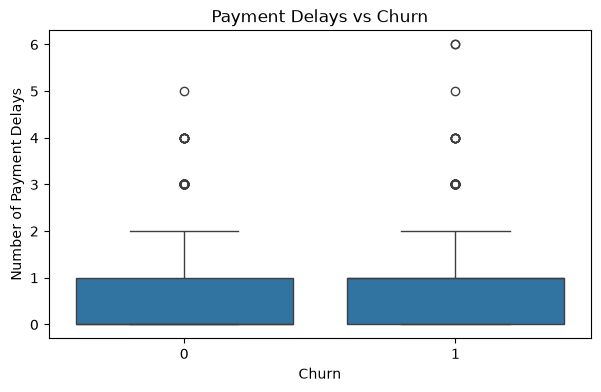

In [8]:
#Login drop vs churn
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="Login_Drop_Percent")
plt.title("Login Activity Drop vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Login Activity Drop (%)")
plt.show()

#Usage comparison
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="Usage_Minutes_30D")
plt.title("30-Day Usage vs Churn")
plt.xlabel("Churn")
plt.ylabel("Usage Minutes (30 Days)")
plt.show()

#Support tickets
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="Support_Tickets")
plt.title("Support Tickets vs Churn")
plt.xlabel("Churn")
plt.ylabel("Support Tickets")
plt.show()

#Payment delays
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="Payment_Delays")
plt.title("Payment Delays vs Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Payment Delays")
plt.show()